In [22]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from scipy.interpolate import interpn
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from functions import *

In [23]:

def spherical_to_cartesian(azimuth_deg, elevation_deg):
    """Конвертируем углы в направляющий вектор"""
    azimuth = np.radians(azimuth_deg)
    elevation = np.radians(elevation_deg)
    x = np.cos(elevation) * np.cos(azimuth)
    y = np.cos(elevation) * np.sin(azimuth)
    z = np.sin(elevation)
    return np.array([x, y, z])

def line_parametric(t, origin, direction):
    """Параметрическое уравнение прямой"""
    return origin + direction * t

def find_intersection(matrix_shape, origin, direction):
    """Находим точки пересечения прямой с границами матрицы"""
    def get_t(axis, boundary):
        return (boundary - origin[axis]) / direction[axis] if direction[axis] != 0 else np.nan
    
    min_bounds = np.array([0, 0, 0])
    max_bounds = np.array(matrix_shape) - 1e-6  #  краевые эффекты
    
    t_enter = []
    t_exit = []
    
    for i in range(3):
        t1 = get_t(i, min_bounds[i])
        t2 = get_t(i, max_bounds[i])
        t_enter.append(min(t1, t2))
        t_exit.append(max(t1, t2))
    
    # Исправленный блок 
    valid_t_enter = [t for t in t_enter if not np.isnan(t)]
    valid_t_exit = [t for t in t_exit if not np.isnan(t)]
    
    t_start = max([0] + valid_t_enter) if valid_t_enter else np.nan 
    t_end = min(valid_t_exit) if valid_t_exit else np.nan    
    
    if np.isnan(t_start) or np.isnan(t_end) or t_start > t_end:
        return np.nan, np.nan
    
    
    # t_start = max(0, *[t for t in t_enter if not np.isnan(t)])
    # t_end = min(*[t for t in t_exit if not np.isnan(t)])
    
    return t_start, t_end

def trilinear_interpolation(matrix, x, y, z):
    """Трилинейная интерполяция"""
    x0, y0, z0 = np.floor([x, y, z]).astype(int)
    x1, y1, z1 = x0 + 1, y0 + 1, z0 + 1
    
    # обработка выхода за границы
    x0, x1 = np.clip([x0, x1], 0, matrix.shape[0]-1)
    y0, y1 = np.clip([y0, y1], 0, matrix.shape[1]-1)
    z0, z1 = np.clip([z0, z1], 0, matrix.shape[2]-1)
    
    xd = (x - x0) / (x1 - x0) if (x1 - x0) != 0 else 0
    yd = (y - y0) / (y1 - y0) if (y1 - y0) != 0 else 0
    zd = (z - z0) / (z1 - z0) if (z1 - z0) != 0 else 0

    c00 = matrix[x0, y0, z0] * (1 - xd) + matrix[x1, y0, z0] * xd
    c01 = matrix[x0, y0, z1] * (1 - xd) + matrix[x1, y0, z1] * xd
    c10 = matrix[x0, y1, z0] * (1 - xd) + matrix[x1, y1, z0] * xd
    c11 = matrix[x0, y1, z1] * (1 - xd) + matrix[x1, y1, z1] * xd

    c0 = c00 * (1 - yd) + c10 * yd
    c1 = c01 * (1 - yd) + c11 * yd

    return c0 * (1 - zd) + c1 * zd


In [26]:
def plot_line_results(V_radial, z0, x, y, z, points, radial_velocity_values, rrf_values, distance, observer_position):
    """
    Визуализация результатов: радиальная скорость и профиль скорости.

    Args:
        V_radial (np.ndarray): 3D массив радиальных скоростей.
        z0 (int): Величина в метрах среза Z.
        x (np.ndarray): Координаты по оси X.
        y (np.ndarray): Координаты по оси Y.
        points (np.ndarray): Точки на линии.
        radial_velocity_values (list): Значения радиальной скорости в точках.
        rrf_values (list): Значения RRF в точках.
        distance (np.ndarray): Расстояния между точками.
        observer_position (tuple): Позиция наблюдателя (x0, y0).
    """
    import matplotlib.pyplot as plt
    import numpy as np

    z_slice = np.argmin(np.abs(z - z0))  # Индекс слоя z

    # Срез радиальной скорости
    radial_slice = V_radial[:, :, z_slice]

    plt.figure(figsize=(14, 6))

    # Подграфик 1: Вид сверху
    plt.subplot(1, 2, 1)
    plt.imshow(
        radial_slice.T,
        extent=[x.min(), x.max(), y.min(), y.max()],
        origin='lower',
        cmap='coolwarm',
        alpha=0.6
    )
    plt.colorbar(label='Радиальная скорость (м/с)')

    # Точки линии
    plt.scatter(
        points[:, 0], points[:, 1],
        c=radial_velocity_values, cmap='coolwarm', s=50, edgecolor='w',
        label='Точки линии'
    )
    plt.plot(points[:, 0], points[:, 1], color='blue', linestyle='-', linewidth=2, label='Линия')

    # Наблюдатель
    plt.scatter(
        observer_position[0]+0, observer_position[1]+0,
        color='red', marker='X', s=100, label='Наблюдатель'
    )

    # Подписи значений у точек
    for i in range(len(points)):
        plt.text(
            points[i, 0], points[i, 1],
            f'{radial_velocity_values[i]:.1f} м/с',
            fontsize=8,
            ha='right',
            va='bottom',
            color='black',
            bbox=dict(boxstyle='round,pad=0.2',
                      edgecolor='white',
                      facecolor='white',
                      alpha=0.7)
        )

    plt.xlabel('X (м)')
    plt.ylabel('Y (м)')
    plt.title(f'Вид сверху (z={z0} м)')
    plt.legend()
    plt.grid(True)

    # Подграфик 2: Профиль скорости
    plt.subplot(1, 2, 2)
    plt.plot(distance, radial_velocity_values, marker='o', linestyle='-', color='b', label='Радиальная скорость')
    plt.plot(distance, rrf_values, marker='s', linestyle='--', color='r', label='RRF')
    plt.xlabel('Расстояние вдоль линии (м)')
    plt.ylabel('Скорость (м/с)')
    plt.title('Профиль скорости')
    plt.legend()
    plt.grid(True)

    # Подписи значений у профиля
    for i in range(len(distance)):
        plt.text(
            distance[i], radial_velocity_values[i],
            f'{radial_velocity_values[i]:.1f} м/с',
            fontsize=8,
            ha='right',
            va='bottom',
            color='black',
            bbox=dict(boxstyle='round,pad=0.2',
                      edgecolor='white',
                      facecolor='white',
                      alpha=0.7)
        )
        plt.text(
            distance[i], rrf_values[i],
            f'{rrf_values[i]:.1f} dbz',
            fontsize=8,
            ha='right',
            va='top',
            color='black',
            bbox=dict(boxstyle='round,pad=0.2',
                      edgecolor='white',
                      facecolor='white',
                      alpha=0.7)
        )

    plt.tight_layout()
    plt.show()

/tmp/ipykernel_31064/3885513840.py:84: RuntimeWarning: divide by zero encountered in scalar divide
  y_idx = (point[1] - origin[1]) / dy
/tmp/ipykernel_31064/3885513840.py:85: RuntimeWarning: divide by zero encountered in scalar divide
  z_idx = (point[2] - origin[2]) / dz
/tmp/ipykernel_31064/2681734391.py:49: RuntimeWarning: invalid value encountered in cast
  x0, y0, z0 = np.floor([x, y, z]).astype(int)


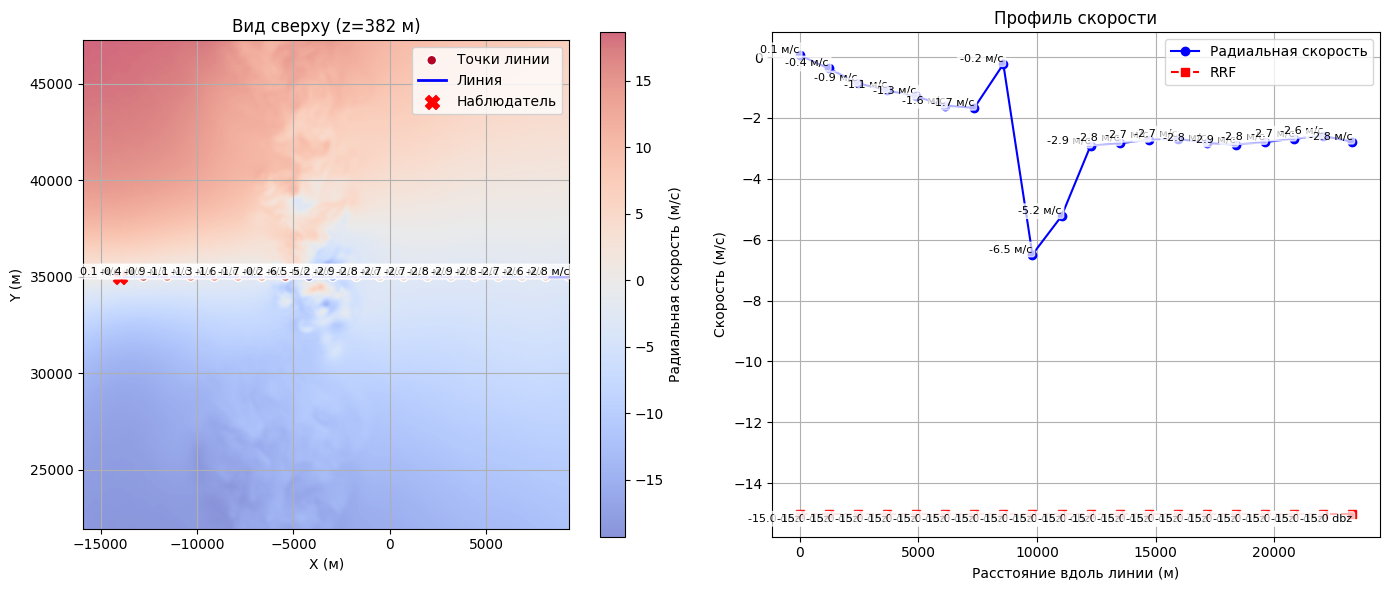

In [29]:
u_data = read_pws_file("../data/DO-220B Reference Supplement/NASA Turbulence Event Scenarios/Official_191_06/flr6-100m-u-48min.faa")
v_data = read_pws_file("../data/DO-220B Reference Supplement/NASA Turbulence Event Scenarios/Official_191_06/flr6-100m-v-48min.faa")
w_data = read_pws_file("../data/DO-220B Reference Supplement/NASA Turbulence Event Scenarios/Official_191_06/flr6-100m-w-48min.faa")


origin = np.array(u_data['origin_m'])  # Начало координат датасета
dx, dy, dz = u_data['resolution_m']     # Шаг сетки
ix, iy, iz = u_data['dimensions']       # Размеры сетки

# Создание сетки в реальных координатах
x = origin[0] + np.arange(ix) * dx
y = origin[1] + np.arange(iy) * dy
z = origin[2] + np.arange(iz) * dz
X, Y, Z = np.meshgrid(x, y, z, indexing='ij')

# Расчет радиальной скорости
# x0, y0, z0 =  -900, 0, 63 # Точка наблюдателя
x0, y0, z0 =  -14000, 35000, 382 # Точка наблюдателя 
# Параметры линии
azimuth_deg = 0 # Горизонтальный угол
elevation_deg = 0  # Вертикальный угол
num_points = 20    # Количество точек



delta_x = X - x0
delta_y = Y - y0
delta_z = Z - z0
r = np.sqrt(delta_x**2 + delta_y**2 + delta_z**2)
with np.errstate(divide='ignore', invalid='ignore'):
    V_radial = (u_data['data'] * delta_x + 
                v_data['data'] * delta_y + 
                w_data['data'] * delta_z) / r
V_radial = np.nan_to_num(V_radial, nan=0.0)



direction = spherical_to_cartesian(azimuth_deg, elevation_deg)

# в реальных координатах
origin_line = np.array([x0, y0, z0])

# пересечения с матрицей
# min_bounds = np.array([x[0], y[0], z[0]])
# max_bounds = np.array([x[-1], y[-1], z[-1]])

matrix_shape = np.array([ix-1, iy-1, iz-1])

direction_normalized = direction / np.array([dx, dy, dz]) 

t_start, t_end = find_intersection(matrix_shape, 
                                  (origin_line - origin)/np.array([dx, dy, dz]), 
                                  direction_normalized)

t_values = np.linspace(t_start, t_end, num_points)
points = origin_line + direction * t_values[:, np.newaxis]  

radial_velocity_values = []
for point in points:
    x_idx = (point[0] - origin[0]) / dx
    y_idx = (point[1] - origin[1]) / dy
    z_idx = (point[2] - origin[2]) / dz
    radial_velocity_values.append(trilinear_interpolation(V_radial, x_idx, y_idx, z_idx))

# print(points)
# print(values)
# print(ix)
# istance = [0.0]
distance = [0.0]  # Начальное расстояние 0 метров

for i in range(1, len(points)):
    dx = points[i][0] - points[i-1][0]
    dy = points[i][1] - points[i-1][1]
    dz = points[i][2] - points[i-1][2]
    segment = np.sqrt(dx**2 + dy**2 + dz**2)
    distance.append(distance[-1] + segment)  #

distance = np.array(distance)

rrf_data = read_pws_file("../data/DO-220B Reference Supplement/NASA Turbulence Event Scenarios/Official_191_06/flr6-100m-rrf-48min.faa")
values_rrf = []
for point in points:
    x_idx = (point[0] - origin[0]) / dx
    y_idx = (point[1] - origin[1]) / dy
    z_idx = (point[2] - origin[2]) / dz
    values_rrf.append(trilinear_interpolation(rrf_data['data'], x_idx, y_idx, z_idx))

plot_line_results(V_radial=V_radial, z0=z0, x=x, y=y, z=z, points=points, radial_velocity_values=radial_velocity_values, rrf_values=values_rrf, distance=distance, observer_position=(x0, y0))


# Шаги изменения
dx = -85.86511509
dy = 4.5

first_x = points[0, 0]
first_y = points[0, 1]
first_z = points[0, 2]

new_data = []
for i in range(1, 100):
    new_x = first_x + i * dx
    new_y = first_y 
    new_z = first_z + i * dy
    new_data.append([new_x, new_y, new_z])

new_data = np.array(new_data)
# print(new_data)

# # --- Вторая линия ---
# u_data = read_pws_file("../data/111/PWS_NASA_Dataset111_u.faa")
# v_data = read_pws_file("../data/111/PWS_NASA_Dataset111_v.faa")
# w_data = read_pws_file("../data/111/PWS_NASA_Dataset111_w.faa")


# # u_data = read_pws_file("../data/DO-220B Reference Supplement/ADWRS/PWS_NASA_Dataset351_W9_4/PWS_NASA_Dataset351_u.faa")
# # v_data = read_pws_file("../data/DO-220B Reference Supplement/ADWRS/PWS_NASA_Dataset351_W9_4/PWS_NASA_Dataset351_v.faa")
# # w_data = read_pws_file("../data/DO-220B Reference Supplement/ADWRS/PWS_NASA_Dataset351_W9_4/PWS_NASA_Dataset351_w.faa")

# origin = np.array(u_data['origin_m'])  # Начало координат датасета
# dx, dy, dz = u_data['resolution_m']     # Шаг сетки
# ix, iy, iz = u_data['dimensions']       # Размеры сетки

# # Создание сетки в реальных координатах

# x = origin[0] + np.arange(ix) * dx
# y = origin[1] + np.arange(iy) * dy
# z = origin[2] + np.arange(iz) * dz
# X, Y, Z = np.meshgrid(x, y, z, indexing='ij')
# x0_2, y0_2, z0_2 = 292.99, 0, 0 
# azimuth_deg_2 = 0
# elevation_deg_2 = 0

# origin_line_2 = np.array([x0_2, y0_2, z0_2])
# direction_2 = spherical_to_cartesian(azimuth_deg_2, elevation_deg_2)
# direction_normalized_2 = direction_2 / np.array([dx, dy, dz])

# t_start_2, t_end_2 = find_intersection(matrix_shape, 
#                                       (origin_line_2 - origin)/np.array([dx, dy, dz]), 
#                                       direction_normalized_2)

# t_values_2 = np.linspace(t_start_2, t_end_2, num_points)
# points_2 = origin_line_2 + direction_2 * t_values_2[:, np.newaxis]

# values_2 = []
# for point in points_2:
#     x_idx = (point[0] - origin[0]) / dx
#     y_idx = (point[1] - origin[1]) / dy
#     z_idx = (point[2] - origin[2]) / dz
#     values_2.append(trilinear_interpolation(V_radial, x_idx, y_idx, z_idx))

# distance_2 = [0.0]
# for i in range(1, len(points_2)):
#     segment = np.linalg.norm(points_2[i] - points_2[i-1])
#     distance_2.append(distance_2[-1] + segment)
# distance_2 = np.array(distance_2)

# values_combined = np.concatenate([radial_velocity_values, values_2[1:]])

# distance_2_shifted = distance_2 + distance[-1]
# distance_combined = np.concatenate([distance, distance_2_shifted[1:]])

# points_combined = np.concatenate([points, points_2[1:]])





# rrf_data = read_pws_file("../data/111/PWS_NASA_Dataset111_rrf.faa")
# values_rrf = []
# for point in points_combined:
#     x_idx = (point[0] - origin[0]) / dx
#     y_idx = (point[1] - origin[1]) / dy
#     z_idx = (point[2] - origin[2]) / dz
#     values_rrf.append(trilinear_interpolation(rrf_data['data'], x_idx, y_idx, z_idx))

# plt.figure(figsize=(14, 6))
# plt.plot(distance_combined, values_combined, label='Радиальная скорость', marker='o', linestyle='-', color='b')
# plt.plot(distance_combined, values_rrf, label='RRF', marker='s', linestyle='--', color='r')
# plt.xlabel('Расстояние, м')
# plt.ylabel('Скорость, м/с')
# plt.title('Объединенные данные двух линий')
# plt.legend()
# plt.grid(True)

# for i in range(len(distance_combined)):
#     plt.text(
#         distance_combined[i], values_combined[i],
#         f'{values_combined[i]:.1f} м/с',
#         fontsize=8,
#         ha='right',
#         va='bottom',
#         color='black',
#         bbox=dict(boxstyle='round,pad=0.2',
#                   edgecolor='white',
#                   facecolor='white',
#                   alpha=0.7)
#     )
#     plt.text(
#         distance_combined[i], values_rrf[i],
#         f'{values_rrf[i]:.1f} dbz',
#         fontsize=8,
#         ha='right',
#         va='top',
#         color='black',
#         bbox=dict(boxstyle='round,pad=0.2',
#                   edgecolor='white',
#                   facecolor='white',
#                   alpha=0.7)
#     )

# plt.show()
